In [2]:
from pathlib import Path
import json
import pandas as pd
import sys
import yaml
import matplotlib.pyplot as plt
import numpy as np

sys.path.append("/home/pirie03/projects/aip-medilab/pirie03/NeedleMicroSeg")

In [3]:
# Paths
DATA_ROOT = Path("/project/6106383/shared/2026-03-11_pwilson_needle-fire-needle-mask")
DATA_DIR = DATA_ROOT / "data"
SPLITS_FILE = DATA_ROOT / "optimum_patient_splits.json"

# Load all .h5 files
all_h5 = sorted(DATA_DIR.glob("*.h5"))

# Count samples per case ID
case_to_sample_count = {}
for p in all_h5:
    case_id = "-".join(p.stem.split("-")[:2])
    case_to_sample_count[case_id] = case_to_sample_count.get(case_id, 0) + 1

# Load split definitions
with open(SPLITS_FILE, "r") as f:
    splits_data = json.load(f)

rows = []

for split_id, split_info in splits_data.items():
    train_cases = split_info.get("train", [])
    val_cases = split_info.get("val", [])

    n_train_patients = len(train_cases)
    n_val_patients = len(val_cases)

    n_train_samples = sum(case_to_sample_count.get(case_id, 0) for case_id in train_cases)
    n_val_samples = sum(case_to_sample_count.get(case_id, 0) for case_id in val_cases)

    rows.append({
        "split_id": split_id,
        "train_patients": n_train_patients,
        "train_samples": n_train_samples,
        "val_patients": n_val_patients,
        "val_samples": n_val_samples,
        "total_patients": n_train_patients + n_val_patients,
        "total_samples": n_train_samples + n_val_samples,
    })

df = pd.DataFrame(rows)

# Rank from highest to lowest train samples
df = df.sort_values(
    by=["train_samples", "train_patients", "split_id"],
    ascending=[False, False, True]
).reset_index(drop=True)

display(df)

,split_id,train_patients,train_samples,val_patients,val_samples,total_patients,total_samples
0,leave-one-center-out_center-HU,177,1699,5,0,182,1699
1,leave-one-center-out_center-UCB,160,1699,22,0,182,1699
2,leave-one-center-out_center-PU,143,1664,39,35,182,1699
3,kfold_cv_fold-2,146,1388,36,311,182,1699
4,kfold_cv_fold-3,146,1376,36,323,182,1699
5,kfold_cv_fold-1,145,1359,37,340,182,1699
6,kfold_cv_fold-0,145,1345,37,354,182,1699
7,kfold_cv_fold-4,146,1328,36,371,182,1699
8,leave-one-center-out_center-OL,142,1157,40,542,182,1699
9,center_UA_cv_fold-1,61,906,15,216,76,1122


In [5]:
# --------------------------------------------------
# Paths
# --------------------------------------------------
REPO_ROOT = Path("/home/pirie03/projects/aip-medilab/pirie03/NeedleMicroSeg")
CONFIG_PATH = REPO_ROOT / "configs/train_2d/full_frame_resize_test_2.yaml"
DATA_ROOT = Path("/project/6106383/shared/2026-03-11_pwilson_needle-fire-needle-mask")
SPLITS_FILE = DATA_ROOT / "optimum_patient_splits.json"

# Add repo root to path
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

# --------------------------------------------------
# Imports from repo
# --------------------------------------------------
from src.data.dataset_2d import NeedleDataset2D
from src.data.extractors_2d import get_extractor
from src.utils.normalization import get_normalizer

# --------------------------------------------------
# User controls
# --------------------------------------------------
SPLIT = "val"                       # "train" or "val"
SPLIT_ID_OVERRIDE = "kfold_cv_fold-0"   # set to None to use config split_id
SAMPLE_IDX = 0                      # which sample within that split to visualize

# --------------------------------------------------
# Load config
# --------------------------------------------------
with open(CONFIG_PATH, "r") as f:
    cfg = yaml.safe_load(f)

split_id = SPLIT_ID_OVERRIDE if SPLIT_ID_OVERRIDE is not None else cfg["data"]["split_id"]

extractor_name = cfg["extractor"]["name"]
extractor_kwargs = cfg["extractor"].get("kwargs", {})

normalizer_name = cfg.get("normalization", {}).get("name", None)

print("Using split:", SPLIT)
print("Using split_id:", split_id)
print("Extractor:", extractor_name, extractor_kwargs)
print("Normalizer:", normalizer_name)

# --------------------------------------------------
# Build dataset pieces
# --------------------------------------------------
extractor = get_extractor(extractor_name)
normalizer = get_normalizer(normalizer_name)

ds = NeedleDataset2D(
    root=DATA_ROOT,
    split=SPLIT,
    split_id=split_id,
    splits_file=SPLITS_FILE,
    extractor_fn=extractor,
    extractor_kwargs=extractor_kwargs,
    normalizer=normalizer,
    transform=None,
)

print("Dataset size:", len(ds))

Using split: val
Using split_id: kfold_cv_fold-0
Extractor: full_frame_resize {'out_hw': [256, 256]}
Normalizer: zscore_per_image
Dataset size: 354


In [6]:
sample = ds[SAMPLE_IDX]

print("Sample keys:", sample.keys())

image = sample["image"]
mask = sample["mask"]

# Convert torch tensors to numpy if needed
if hasattr(image, "detach"):
    image = image.detach().cpu().numpy()
if hasattr(mask, "detach"):
    mask = mask.detach().cpu().numpy()

# Remove channel dim if shape is (1, H, W)
if image.ndim == 3 and image.shape[0] == 1:
    image_2d = image[0]
else:
    image_2d = image

if mask.ndim == 3 and mask.shape[0] == 1:
    mask_2d = mask[0]
else:
    mask_2d = mask

print("image shape:", image_2d.shape)
print("mask shape:", mask_2d.shape)

# Helpful metadata if present
for k in ["case_id", "sample_id", "cine_id", "annotation_index", "needle_mask_annotation_index", "metadata"]:
    if k in sample:
        print(f"{k}:", sample[k])

Sample keys: dict_keys(['image', 'mask', 'metadata', 'cine_id', 'needle_mask_annotation_index', 'h5_path'])
image shape: (256, 256)
mask shape: (256, 256)
cine_id: OL-015-014
needle_mask_annotation_index: 44
metadata: {'cine_id': 'OL-015-014', 'bimg_path': 'data/OPTIMUM_RAW_DATABASE/OL/OL-015/Cines/ExactData/20220615103541824/20220615103541886/20220615105445604/9418266944843727946388219273541779.bimg', 'annotator': 'Paul Wilson', 'annotation_date': '2025-07-15 15:46:49.033927', 'needle_fire_frame': 44, 'last_frame_before_needle_insertion': 19, 'needle_mask_annotation_index': 44, 'tail_h': 22.491260782733875, 'tail_w': 43.789343941220494, 'tip_h': 11.909943161664817, 'tip_w': 29.22789767369427, 'trim_range': False}


In [9]:
def show_sample(ds, sample_idx):
    sample = ds[sample_idx]

    image = sample["image"]
    mask = sample["mask"]

    if hasattr(image, "detach"):
        image = image.detach().cpu().numpy()
    if hasattr(mask, "detach"):
        mask = mask.detach().cpu().numpy()

    if image.ndim == 3 and image.shape[0] == 1:
        image = image[0]
    if mask.ndim == 3 and mask.shape[0] == 1:
        mask = mask[0]

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    # 1. image
    axes[0].imshow(image_2d, cmap="gray")
    axes[0].set_title("Image")
    axes[0].axis("off")

    # 2. mask
    axes[1].imshow(mask_2d, cmap="gray")
    axes[1].set_title("Mask")
    axes[1].axis("off")

    # 3. overlay (FIXED)
    masked = np.ma.masked_where(mask_2d == 0, mask_2d)

    axes[2].imshow(image_2d, cmap="gray")
    axes[2].imshow(masked, cmap="autumn", alpha=0.6)
    axes[2].set_title("Mask Overlay")
    axes[2].axis("off")

    plt.tight_layout()
    plt.show()

    for k in ["case_id", "sample_id", "cine_id", "annotation_index", "needle_mask_annotation_index", "metadata"]:
        if k in sample:
            print(f"{k}: {sample[k]}")

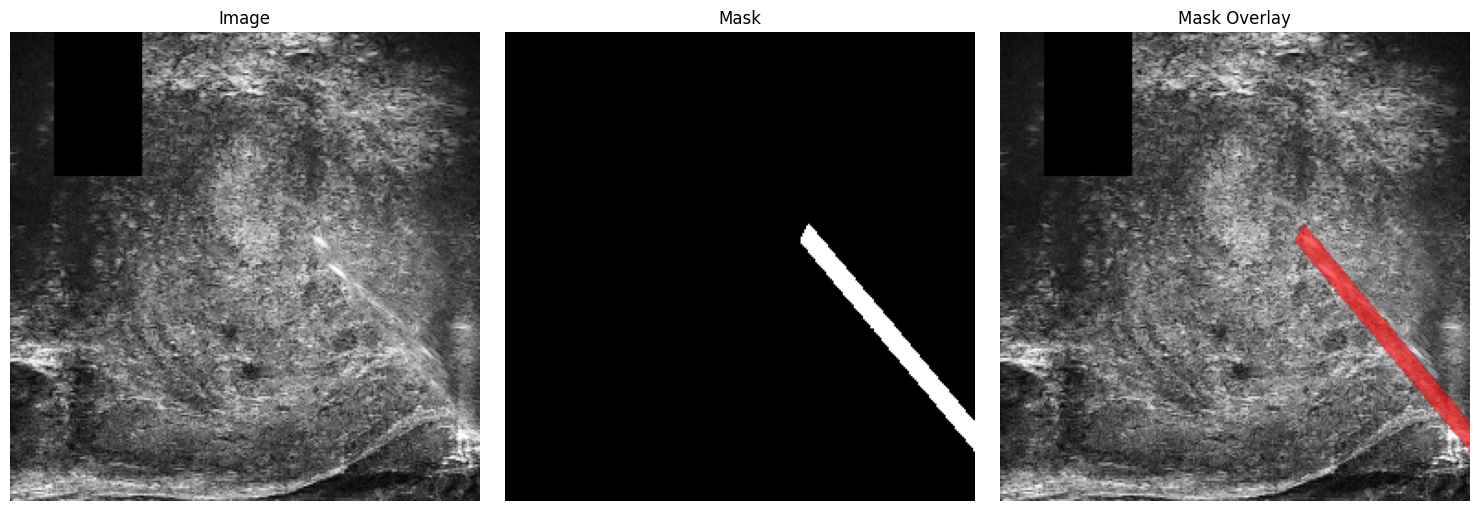

cine_id: OL-015-014
needle_mask_annotation_index: 44
metadata: {'cine_id': 'OL-015-014', 'bimg_path': 'data/OPTIMUM_RAW_DATABASE/OL/OL-015/Cines/ExactData/20220615103541824/20220615103541886/20220615105445604/9418266944843727946388219273541779.bimg', 'annotator': 'Paul Wilson', 'annotation_date': '2025-07-15 15:46:49.033927', 'needle_fire_frame': 44, 'last_frame_before_needle_insertion': 19, 'needle_mask_annotation_index': 44, 'tail_h': 22.491260782733875, 'tail_w': 43.789343941220494, 'tip_h': 11.909943161664817, 'tip_w': 29.22789767369427, 'trim_range': False}


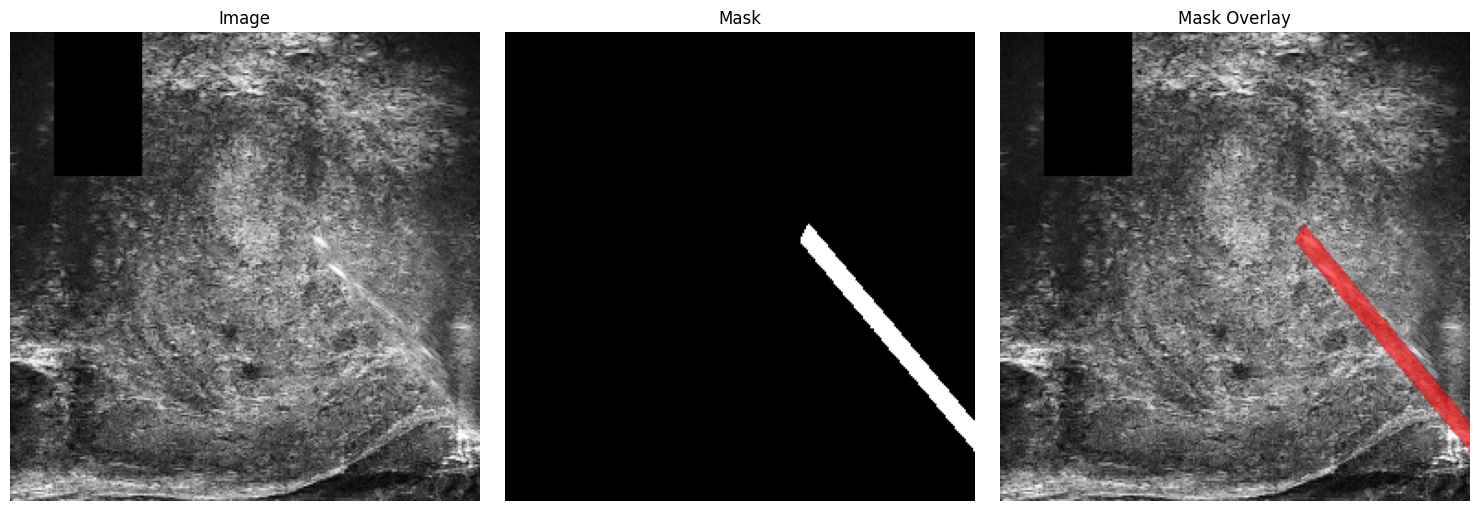

cine_id: OL-015-024
needle_mask_annotation_index: 37
metadata: {'cine_id': 'OL-015-024', 'bimg_path': 'data/OPTIMUM_RAW_DATABASE/OL/OL-015/Cines/ExactData/20220615103541824/20220615103541886/20220615105445604/122344389986394998577523517359724.bimg', 'annotator': 'Luca Scalisi', 'annotation_date': '2025-07-17 14:02:29.449809', 'needle_fire_frame': 37, 'last_frame_before_needle_insertion': 39, 'needle_mask_annotation_index': 37, 'tail_h': 22.77639168144198, 'tail_w': 43.83732462426077, 'tip_h': 11.941752138794609, 'tip_w': 29.46336949768193, 'trim_range': False}


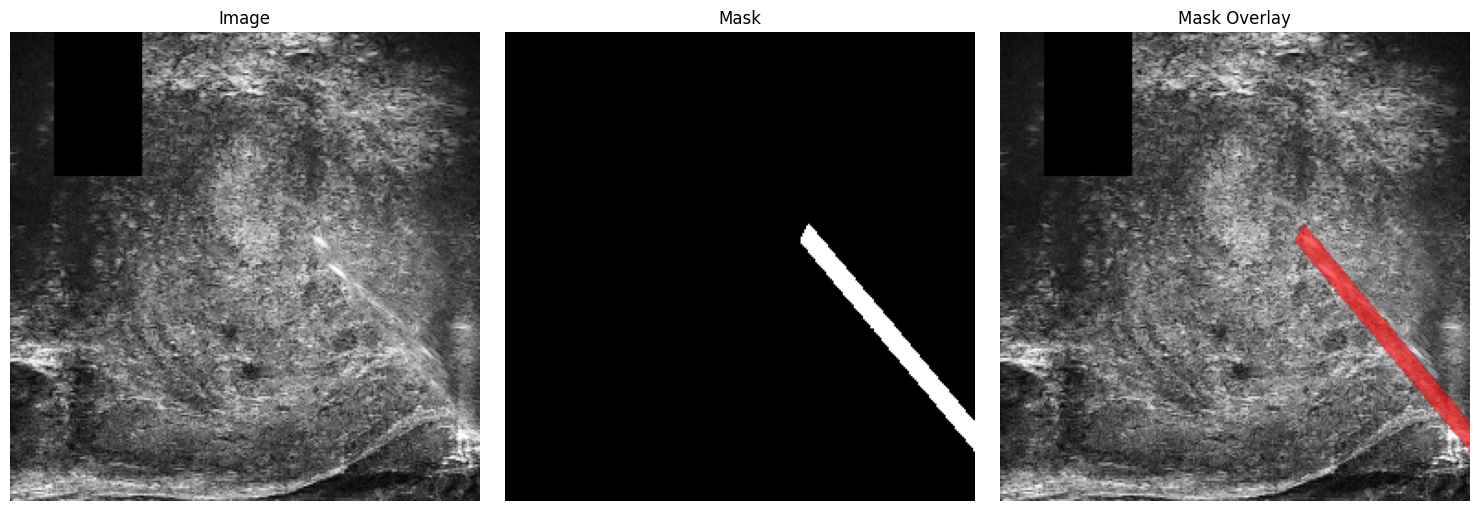

cine_id: OL-021-026
needle_mask_annotation_index: 37
metadata: {'cine_id': 'OL-021-026', 'bimg_path': 'data/OPTIMUM_RAW_DATABASE/OL/OL-021/Cines/ExactData/20220727102337130/20220727102337177/20220727102408986/325219597938651715784762227876394883.bimg', 'annotator': 'Luca Scalisi', 'annotation_date': '2025-07-17 14:02:29.449809', 'needle_fire_frame': 37, 'last_frame_before_needle_insertion': 21, 'needle_mask_annotation_index': 37, 'tail_h': 21.27675647505729, 'tail_w': 41.319539413303865, 'tip_h': 9.67552263059789, 'tip_w': 27.556858959040248, 'trim_range': False}


In [10]:
show_sample(ds, 0)
show_sample(ds, 10)
show_sample(ds, 25)